# 🔍 Fraud Detection in Financial Transactions

---

## 📌 Project Overview
This project builds a **Machine Learning system** to detect
fraudulent credit card transactions from a highly imbalanced
real-world dataset using Python.

---

## 📊 Dataset Information
| Property | Value |
|---|---|
| Total Transactions | 2,84,807 |
| Normal Transactions | 2,84,315 (99.83%) |
| Fraud Transactions | 492 (0.17%) |
| Total Features | 31 columns |
| Time Range | 0 to 1,72,792 seconds (~48 hours of data) |
| Min Transaction Amount | ₹ 0.00 |
| Max Transaction Amount | ₹ 25,691.16 |
| Average Transaction Amount | ₹ 88.35 |
| Missing Values | None |

---

## 🔐 About the Features
| Column | Description |
|---|---|
| `Time` | Seconds elapsed between this and first transaction |
| `V1 to V28` | Anonymized features (PCA transformed for privacy) |
| `Amount` | Transaction amount in currency |
| `Class` | Target variable → 0 = Normal, 1 = Fraud |

---

## ⚠️ Key Challenge — Class Imbalance
Out of every **1000 transactions**, only **1.7 are fraud.**
This extreme imbalance makes detection very difficult.
We use **SMOTE** to fix this problem.

---

## 🛠️ Tools & Techniques Used
| Category | Tools |
|---|---|
| Language | Python |
| Data Handling | Pandas, NumPy |
| Visualization | Matplotlib, Seaborn |
| Class Balancing | SMOTE (imbalanced-learn) |
| ML Model | Random Forest Classifier |
| Evaluation | Confusion Matrix, Precision, Recall, F1-Score |

---

## 📋 Project Steps
1. 📦 Import Libraries
2. 📂 Load Dataset
3. 🔎 Exploratory Data Analysis (EDA)
4. 🧹 Data Cleaning
5. 📊 Visualize Class Imbalance
6. ✂️ Separate Features (X) and Target (y)
7. ⚖️ Apply SMOTE to Balance Classes
8. 🔀 Train / Test Split
9. 🤖 Train Random Forest Model
10. 📏 Evaluate Model Performance

---

## 👤 Author
**Yash Patel**
| B.E. Information Technology
| LDRP Institute of Technology & Research, Gandhinagar.

first step is import libraries of python which will used in project.

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


after importing libraries, our data will give to the machine for understanding which type of data is this.

In [5]:
df = pd.read_csv("creditcard.csv")

after reading all data find how many rows and columns are exists.

In [6]:
print(df.shape)

(17918, 31)


then must check any missing values are exist or not. If exist and you leave them, model will crash or give wrong results. so, must fix them first.

In [7]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        1
V6        1
V7        1
V8        1
V9        1
V10       1
V11       1
V12       1
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


check how many normal transactions and fraud transactions are exists.

In [8]:
print(df['Class'].value_counts())

Class
0.0    17836
1.0       81
Name: count, dtype: int64


in our data missing values are exists, so it cleans first.

In [9]:
df = df.dropna()

print("After removing missing values:", df.shape)

df['Class'] = df['Class'].astype(int)

print(df['Class'].value_counts())

After removing missing values: (17917, 31)
Class
0    17836
1       81
Name: count, dtype: int64


0 = Normal transaction
1 = Fraud transaction.
Numbers tells you there's imbalance, but a chart makes it visually.

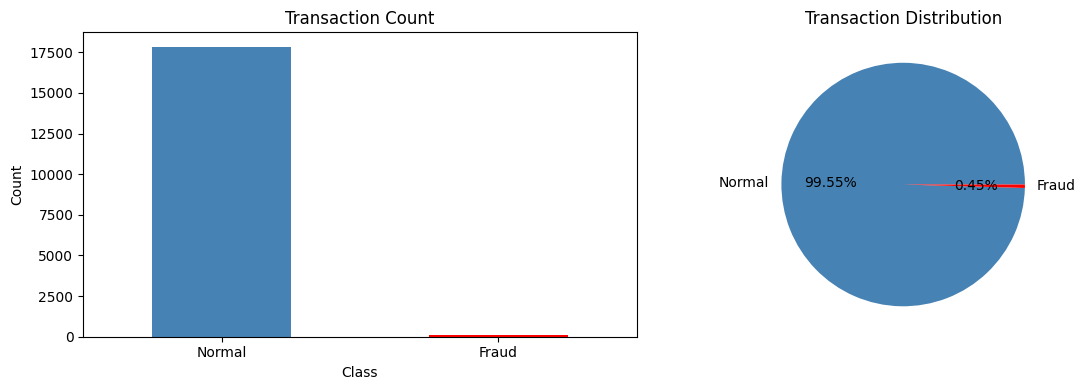

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Class'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=['steelblue', 'red'],
    title='Transaction Count'
)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(
    ['Normal', 'Fraud'],
    rotation=0
)


df['Class'].value_counts().plot(
    kind='pie',
    ax=axes[1],
    labels=['Normal', 'Fraud'],
    autopct='%1.2f%%',
    colors=['steelblue', 'red'],
    title='Transaction Distribution'
)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

for train ML model, i want to devide data into X and Y parts. (X = Question, Y = Answer).Question is our all existant columns except class column, because class column is answer.

In [11]:
X = df.drop('Class', axis=1)
y = df['Class']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())

X shape: (17917, 30)
y shape: (17917,)

Class distribution:
Class
0    17836
1       81
Name: count, dtype: int64


i want the model to figureout for itself whether this transaction is fraud or normal by understanding patterns of data.for understanding data and make strong and powerful model SMOTE method will be helpful.

In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("BEFORE SMOTE:")
print(y.value_counts())

print("\nAFTER SMOTE:")
print(y_resampled.value_counts())

BEFORE SMOTE:
Class
0    17836
1       81
Name: count, dtype: int64

AFTER SMOTE:
Class
0    17836
1    17836
Name: count, dtype: int64


for testing our model, data is devided into two parts: training_set(80%) & testing_set(20%).

training_set = 80% -> model learn from this



testing_set = 20% -> model get tested on unseen data

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (28537, 30)
Testing size: (7135, 30)


for more accuracy, voting system is helpful it's called random forest method.

In [14]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


after successfully trained model, check how good model is. for this process confusion metrics method will helpful.

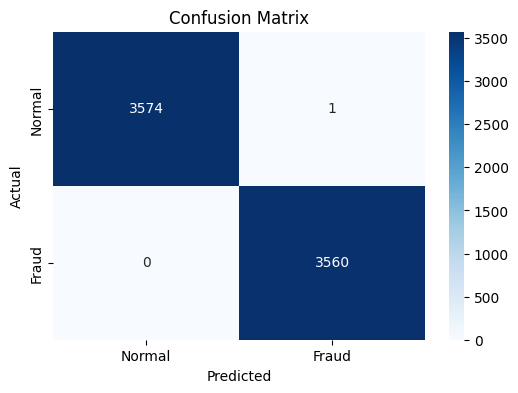

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      3575
       Fraud       1.00      1.00      1.00      3560

    accuracy                           1.00      7135
   macro avg       1.00      1.00      1.00      7135
weighted avg       1.00      1.00      1.00      7135



In [15]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Fraud'],
    yticklabels=['Normal', 'Fraud']
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred,
      target_names=['Normal', 'Fraud']))

In [16]:
final_df = X_resampled.copy()

final_df['Class'] = y_resampled

final_df.to_csv("fraud_dashboard_data.csv", index=False)

print("CSV file exported successfully!")

CSV file exported successfully!


TN = True Negative  -> Correctly predicted Normal✅

TP = True Positive -> Correctly predicted Fraud✅

FP = False Positive -> Predicted Fraud but was actually Normal❌

FN = False Negative -> Predicted Normal but was actually Fraud❌

#                             Our model is trained successfully with 100% accuracy🥳🎉